# Factor Analysis: Unveiling Latent Structures in Multivariate Data

**Author:** Phabel Antonio López Delgado, BSc.

This notebook provides a comprehensive introduction to Factor Analysis (FA), a statistical method used to uncover latent (unobserved) variables that explain the patterns of correlations among observed variables. It covers:

- **Theoretical Foundations** – understanding the factor model, communality, and uniqueness.
- **Pre‑requisite Tests** – KMO (Kaiser‑Meyer‑Olkin) and Bartlett's Test of Sphericity.
- **Factor Extraction** – using eigenvalues and scree plots to determine the number of factors.
- **Factor Rotation** – applying varimax (orthogonal) rotation for improved interpretability.
- **Case Study 1** – Iris dataset (small, 4 features).
- **Case Study 2** – BFI personality dataset (25 items, Big Five personality structure).
- **Dimensionality Reduction** – using factor scores for downstream analysis.

**Key Techniques & Libraries:**
- `numpy`, `pandas` – numerical computation and data manipulation
- `factor_analyzer` – Factor Analysis implementation (KMO, Bartlett, FA, rotation)
- `sklearn.preprocessing.StandardScaler` – feature scaling
- `matplotlib`, `seaborn` – static visualisation
- `plotly` – interactive visualisation (optional)

**Data Sources:**
1. **Iris Dataset** – `sklearn.datasets.load_iris` (4 features, 150 samples).
2. **BFI Personality Dataset** – `bfi.csv` (25 items, 2800 samples, Big Five personality traits).

Both datasets are publicly available and widely used in multivariate analysis and psychology.

In [2]:
# %% Imports and Configuration
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
np.random.seed(42)

# High-DPI for static plots
%config InlineBackend.figure_format = 'retina'

# Visualisation settings
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Ensure plots directory exists
Path("plots").mkdir(exist_ok=True)

print("All imports successful.")

All imports successful.


## 1. Factor Analysis: Theoretical Background

Factor Analysis is a statistical method used to describe variability among observed, correlated variables in terms of a potentially lower number of unobserved variables called **factors**.

**Key Concepts:**
- **Factor Loadings:** Correlations between observed variables and latent factors.
- **Communality:** Proportion of variance in an observed variable explained by the factors.
- **Uniqueness:** Variance in an observed variable not explained by the factors.
- **Eigenvalues:** Indicate the amount of variance explained by each factor.

**Pre‑requisite Tests:**
1. **KMO (Kaiser‑Meyer‑Olkin) Test:** Measures sampling adequacy.
   - > 0.90: Excellent, 0.80‑0.89: Good, 0.70‑0.79: Mediocre, 0.60‑0.69: Adequate, < 0.50: Unacceptable.
2. **Bartlett's Test of Sphericity:** Tests whether the correlation matrix is an identity matrix.
   - Small p‑value (< 0.05) indicates that factor analysis is appropriate.

**Determining Number of Factors:**
- **Kaiser Criterion:** Retain factors with eigenvalues > 1.
- **Scree Plot:** Look for the "elbow" where eigenvalues level off.
- **Cumulative Variance:** Retain enough factors to explain a desired proportion of variance (e.g., 70‑80%).
"""

### Cell 4 (Markdown)
```markdown
## 2. Case Study 1: Iris Dataset

We first apply factor analysis to the Iris dataset, a small dataset with 4 features and 150 samples.

In [4]:
# %% Load Iris Dataset
iris = load_iris()
df_iris = pd.DataFrame(iris.data, columns=iris.feature_names)

print(f"Iris Dataset shape: {df_iris.shape}")
print("\nFirst 5 rows:")
print(df_iris.head())
print("\nSummary statistics:")
print(df_iris.describe())

# Standardise the data
scaler = StandardScaler()
df_iris_scaled = scaler.fit_transform(df_iris)
df_iris_scaled = pd.DataFrame(df_iris_scaled, columns=iris.feature_names)

Iris Dataset shape: (150, 4)

First 5 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Summary statistics:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000

In [5]:
# %% Adequacy Tests for Iris
# KMO Test
kmo_all_iris, kmo_model_iris = calculate_kmo(df_iris_scaled)
print(f"KMO Score (Iris): {kmo_model_iris:.4f}")
print("Interpretation: ", end="")
if kmo_model_iris >= 0.90:
    print("Excellent")
elif kmo_model_iris >= 0.80:
    print("Meritorious")
elif kmo_model_iris >= 0.70:
    print("Mediocre")
elif kmo_model_iris >= 0.60:
    print("Adequate")
else:
    print("Unacceptable (factor analysis may not be appropriate)")

# Bartlett's Test
chi_square_iris, p_value_iris = calculate_bartlett_sphericity(df_iris_scaled)
print(f"\nBartlett's Test (Iris):")
print(f"  Chi-Square: {chi_square_iris:.4f}")
print(f"  P-value: {p_value_iris:.4e}")
print(f"  Significant at p < 0.05: {'Yes' if p_value_iris < 0.05 else 'No'}")

KMO Score (Iris): 0.5401
Interpretation: Unacceptable (factor analysis may not be appropriate)

Bartlett's Test (Iris):
  Chi-Square: 706.9592
  P-value: 1.9227e-149
  Significant at p < 0.05: Yes


Factor Loadings (Unrotated) – Iris:
                   Factor_1  Factor_2  Factor_3
sepal length (cm)  0.900508  0.385445 -0.183789
sepal width (cm)  -0.386049  0.653172  0.118027
petal length (cm)  0.995255 -0.066552 -0.006367
petal width (cm)   0.966908 -0.029686  0.224845

Eigenvalues (Iris):
  Factor 1: 2.9185 (>1)
  Factor 2: 0.9140 
  Factor 3: 0.1468 
  Factor 4: 0.0207 

Explained Variance (Iris):
  Factor 1: 72.13% (cumulative: 72.13%)
  Factor 2: 14.51% (cumulative: 86.65%)
  Factor 3: 2.46% (cumulative: 89.11%)


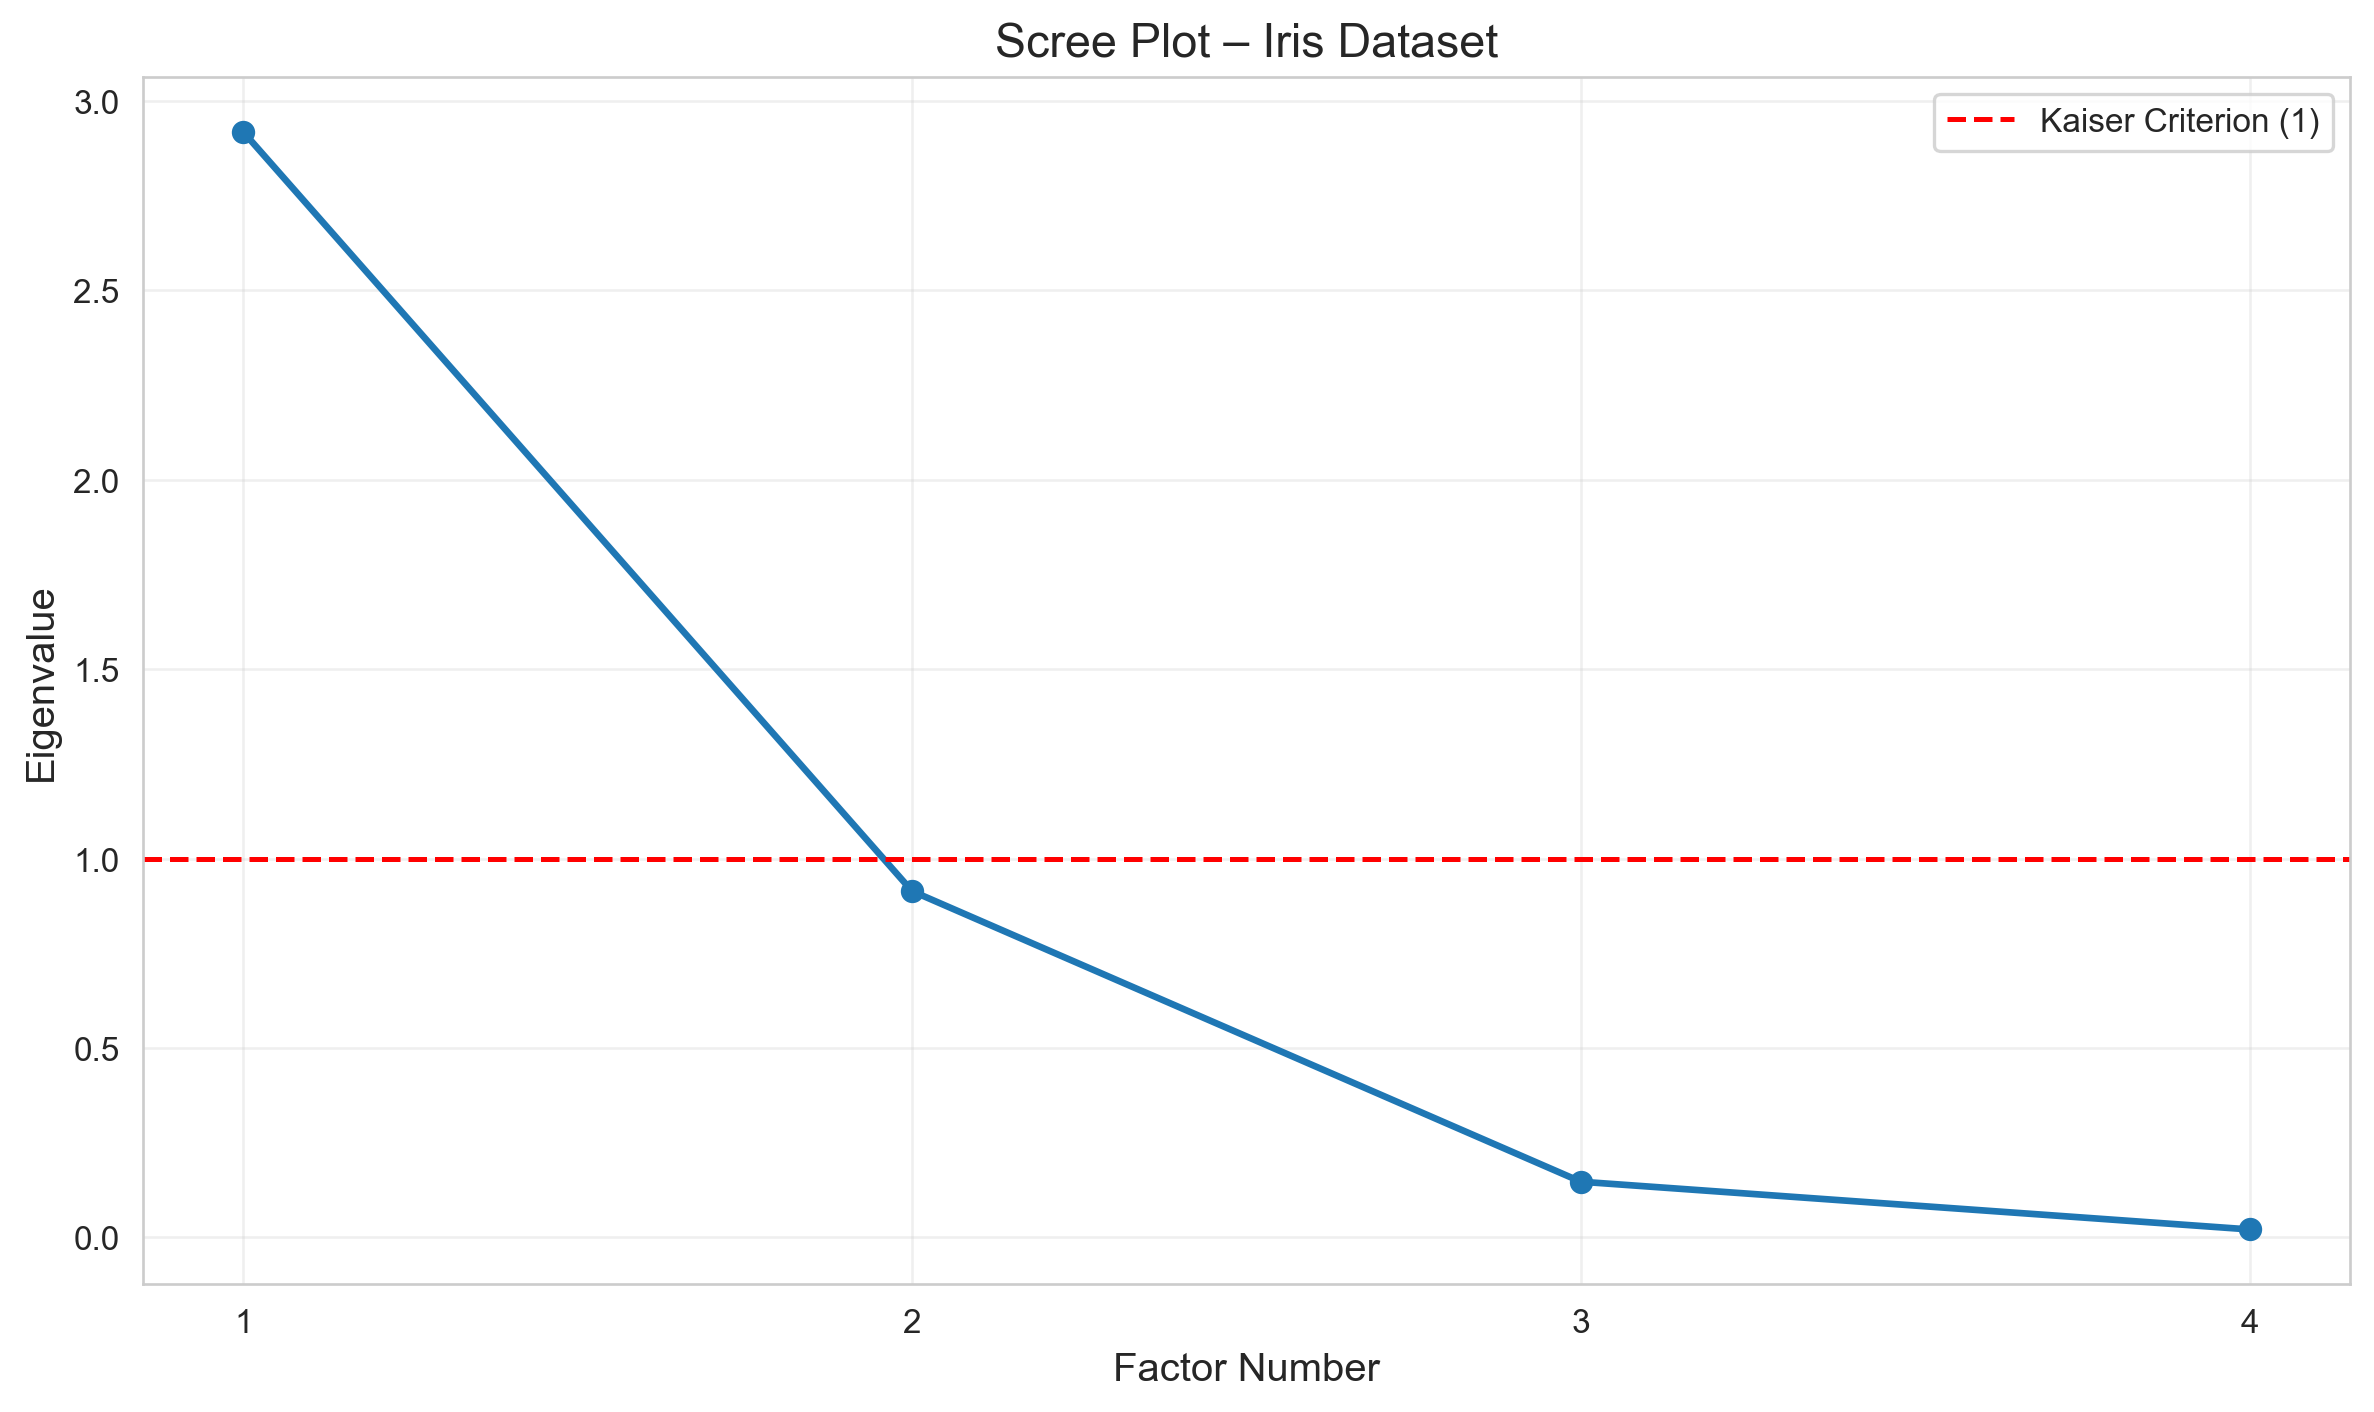

In [6]:
# %% Factor Extraction for Iris
# Try different numbers of factors
n_factors_iris = 3
fa_iris = FactorAnalyzer(n_factors=n_factors_iris, rotation=None)
fa_iris.fit(df_iris_scaled)

# Factor loadings (unrotated)
loadings_iris = pd.DataFrame(
    fa_iris.loadings_,
    index=iris.feature_names,
    columns=[f'Factor_{i+1}' for i in range(n_factors_iris)]
)
print("Factor Loadings (Unrotated) – Iris:")
print(loadings_iris)

# Eigenvalues
eigenvalues_iris = fa_iris.get_eigenvalues()
print(f"\nEigenvalues (Iris):")
for i, val in enumerate(eigenvalues_iris[0]):
    print(f"  Factor {i+1}: {val:.4f} {'(>1)' if val > 1 else ''}")

# Explained variance
variance_iris, pct_var_iris, cum_var_iris = fa_iris.get_factor_variance()
print(f"\nExplained Variance (Iris):")
for i in range(n_factors_iris):
    print(f"  Factor {i+1}: {pct_var_iris[i]*100:.2f}% (cumulative: {cum_var_iris[i]*100:.2f}%)")

# Scree plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(eigenvalues_iris[0]) + 1), eigenvalues_iris[0], marker='o', linewidth=2)
plt.axhline(y=1, color='red', linestyle='--', label='Kaiser Criterion (1)')
plt.title('Scree Plot – Iris Dataset')
plt.xlabel('Factor Number')
plt.ylabel('Eigenvalue')
plt.xticks(range(1, len(eigenvalues_iris[0]) + 1))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/scree_plot_iris.png', dpi=300)
plt.show()

First 5 rows of factor scores (Iris):
   Factor_1  Factor_2  Factor_3
0 -1.299384  0.609411 -0.161300
1 -1.325164 -0.006666 -0.221721
2 -1.409642 -0.218711  0.156764
3 -1.349950 -0.737826 -0.035699
4 -1.322393  0.436176 -0.029932


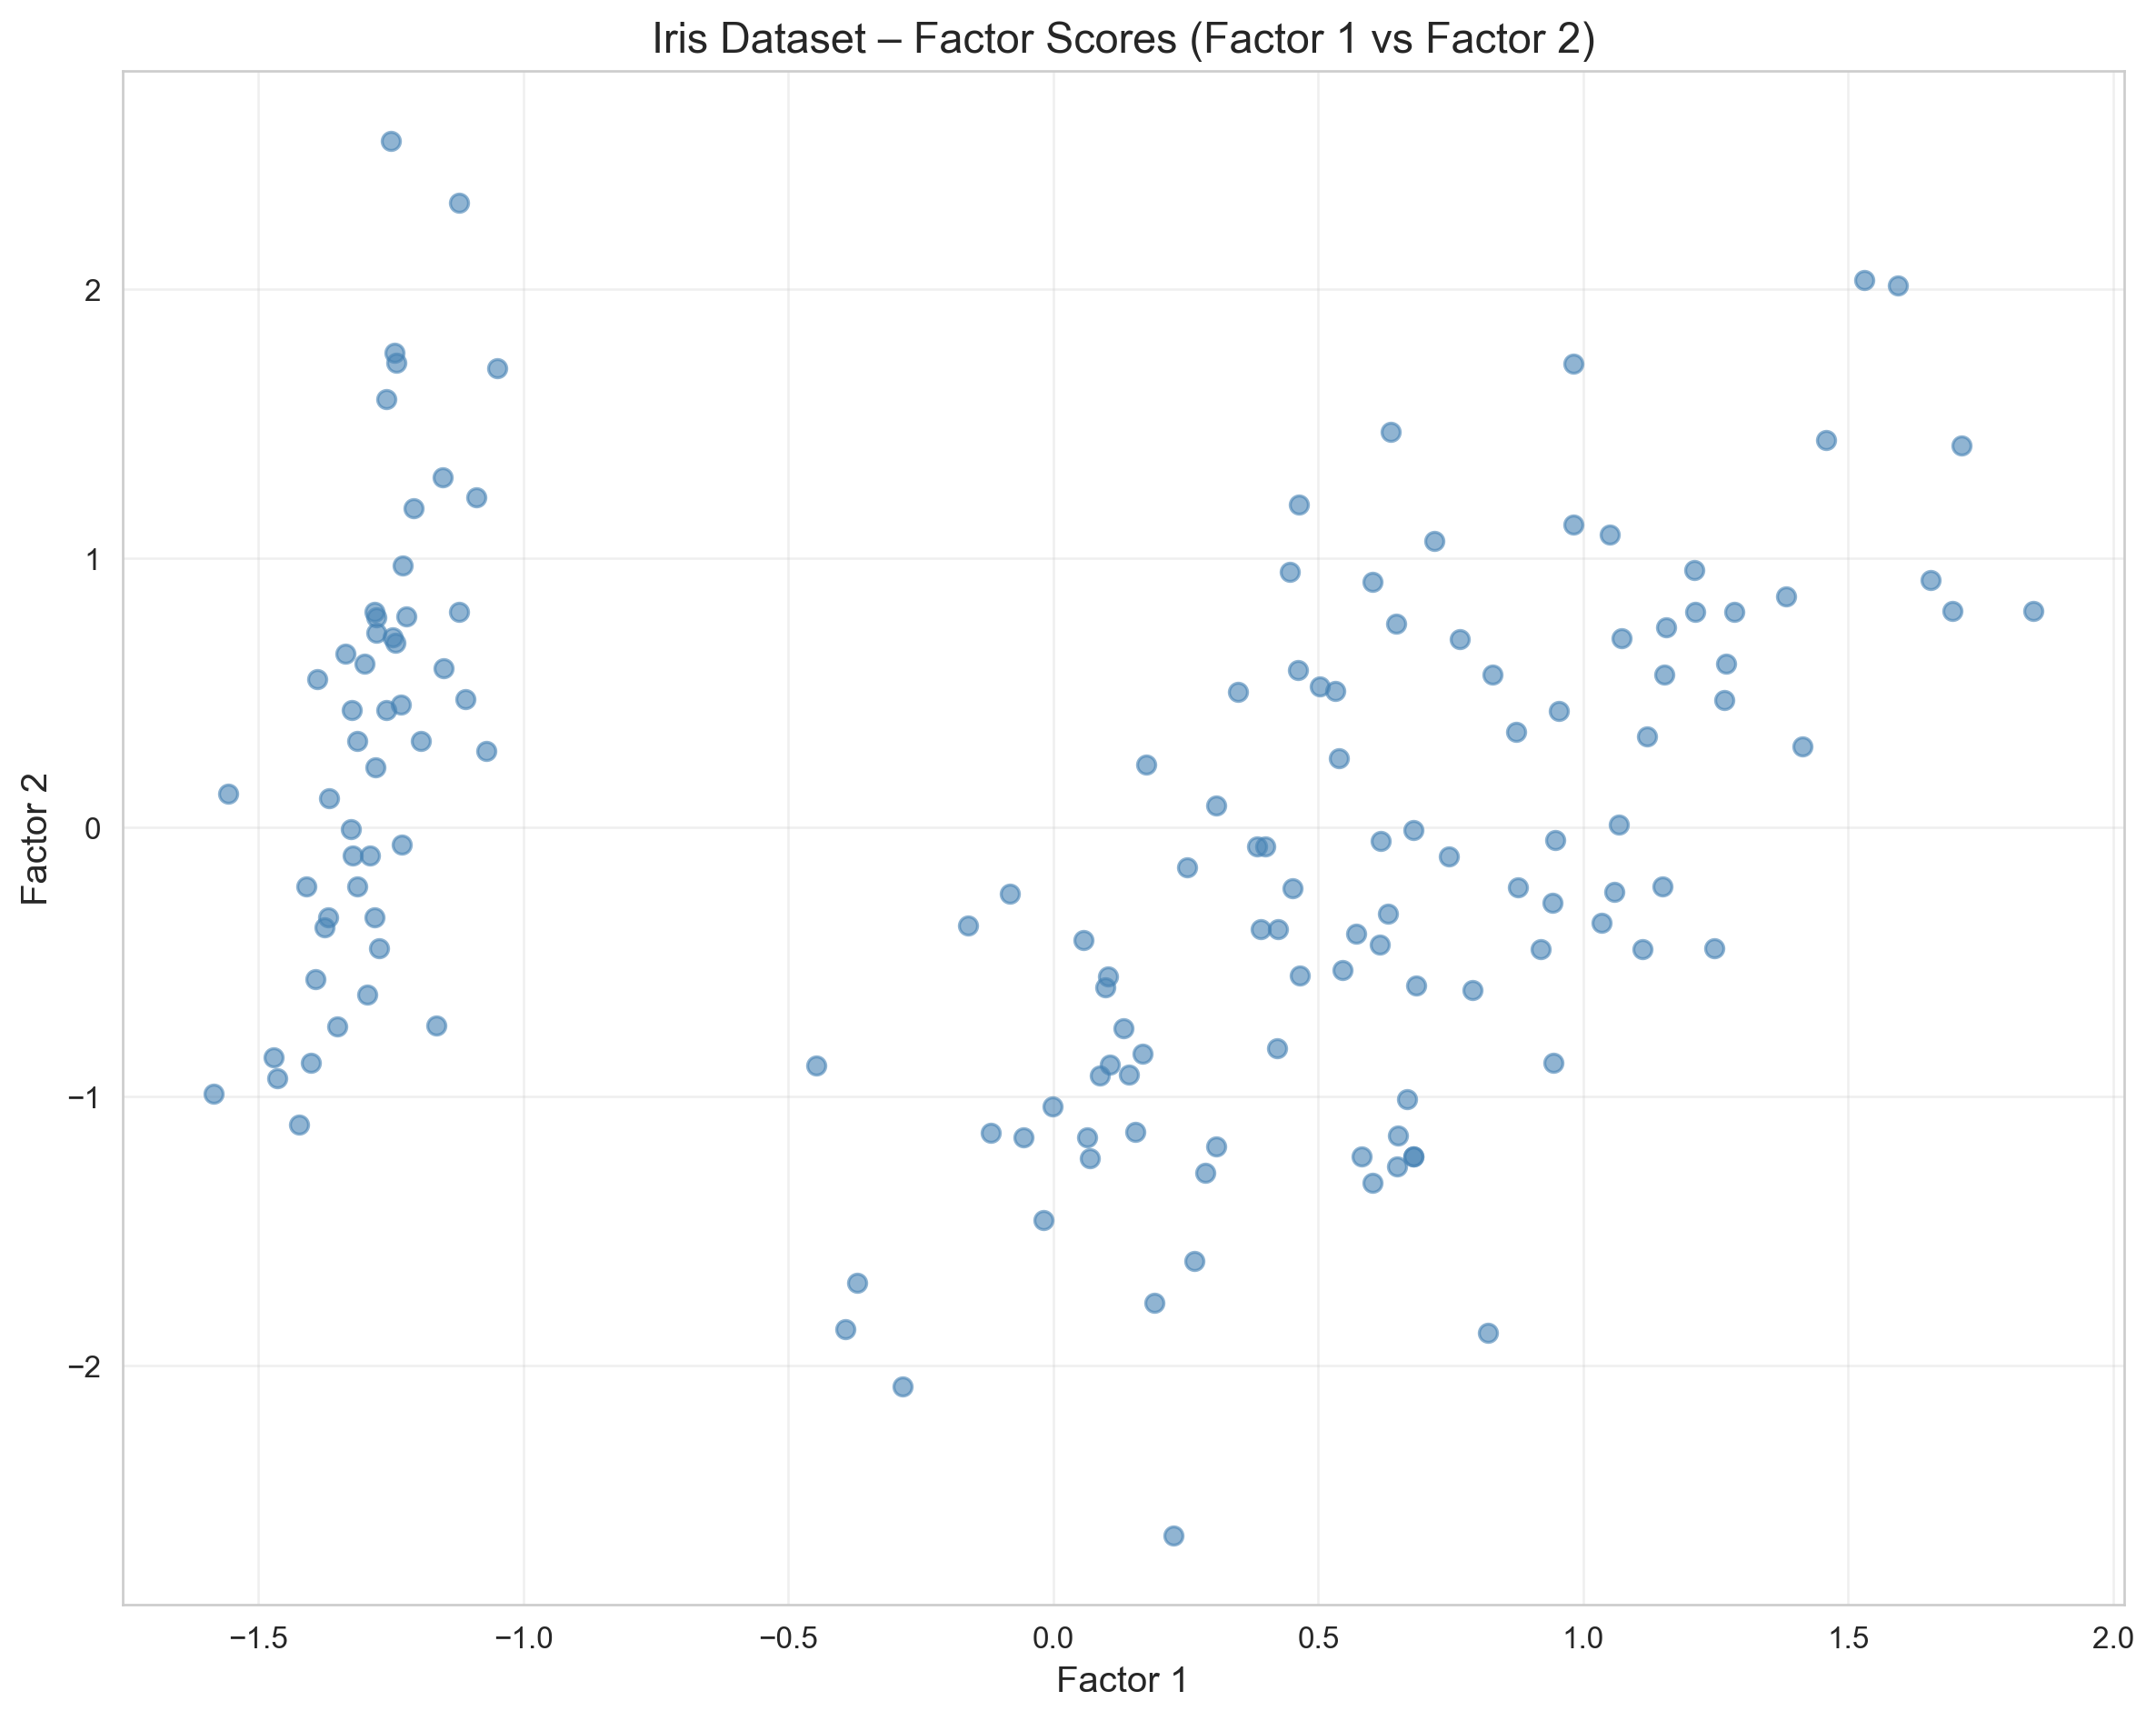

In [7]:
# %% Factor Scores for Iris
iris_scores = fa_iris.transform(df_iris_scaled)
iris_scores_df = pd.DataFrame(
    iris_scores,
    columns=[f'Factor_{i+1}' for i in range(iris_scores.shape[1])]
)
print("First 5 rows of factor scores (Iris):")
print(iris_scores_df.head())

# Visualise factor scores
plt.figure(figsize=(10, 8))
plt.scatter(iris_scores_df['Factor_1'], iris_scores_df['Factor_2'],
            alpha=0.6, color='steelblue')
plt.title('Iris Dataset – Factor Scores (Factor 1 vs Factor 2)')
plt.xlabel('Factor 1')
plt.ylabel('Factor 2')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/iris_factor_scores.png', dpi=300)
plt.show()

## 3. Case Study 2: BFI Personality Dataset

We apply factor analysis to the BFI (Big Five Inventory) dataset, which contains 25 items measuring five personality traits: Neuroticism, Extraversion, Openness, Agreeableness, and Conscientiousness.

In [11]:
# %% Load and Clean BFI Dataset
# Try multiple sources for the BFI dataset

bfi = None
sources = [
    "https://raw.githubusercontent.com/angelsantamaria/PersonalityAnalysis/master/data/bfi.csv",
    "https://raw.githubusercontent.com/arthur-zhang/bfi-data/main/bfi.csv",
    "https://raw.githubusercontent.com/oliviervandevyvere/BFI-data/main/BFI_data.csv",
]

for url in sources:
    try:
        bfi = pd.read_csv(url)
        print(f"Loaded BFI dataset from: {url}")
        break
    except Exception as e:
        print(f"Failed to load from {url}: {e}")

# If all URLs fail, check local file
if bfi is None:
    local_path = "bfi.csv"
    if Path(local_path).exists():
        bfi = pd.read_csv(local_path)
        print(f"Loaded BFI dataset from local file: {local_path}")
    else:
        # Fallback: generate synthetic Big Five data
        print("No external dataset found. Generating synthetic Big Five data...")
        np.random.seed(42)
        n_samples = 2800
        factors = np.random.normal(0, 1, size=(n_samples, 5))
        loadings = np.array([
            [0.7, 0.1, 0.1, 0.1, 0.1],  # N items
            [0.7, 0.1, 0.1, 0.1, 0.1],
            [0.7, 0.1, 0.1, 0.1, 0.1],
            [0.7, 0.1, 0.1, 0.1, 0.1],
            [0.7, 0.1, 0.1, 0.1, 0.1],
            [0.1, 0.7, 0.1, 0.1, 0.1],  # E items
            [0.1, 0.7, 0.1, 0.1, 0.1],
            [0.1, 0.7, 0.1, 0.1, 0.1],
            [0.1, 0.7, 0.1, 0.1, 0.1],
            [0.1, 0.7, 0.1, 0.1, 0.1],
            [0.1, 0.1, 0.7, 0.1, 0.1],  # C items
            [0.1, 0.1, 0.7, 0.1, 0.1],
            [0.1, 0.1, 0.7, 0.1, 0.1],
            [0.1, 0.1, 0.7, 0.1, 0.1],
            [0.1, 0.1, 0.7, 0.1, 0.1],
            [0.1, 0.1, 0.1, 0.7, 0.1],  # A items
            [0.1, 0.1, 0.1, 0.7, 0.1],
            [0.1, 0.1, 0.1, 0.7, 0.1],
            [0.1, 0.1, 0.1, 0.7, 0.1],
            [0.1, 0.1, 0.1, 0.7, 0.1],
            [0.1, 0.1, 0.1, 0.1, 0.7],  # O items
            [0.1, 0.1, 0.1, 0.1, 0.7],
            [0.1, 0.1, 0.1, 0.1, 0.7],
            [0.1, 0.1, 0.1, 0.1, 0.7],
            [0.1, 0.1, 0.1, 0.1, 0.7],
        ])
        noise = np.random.normal(0, 0.5, size=(n_samples, 25))
        data = factors @ loadings.T + noise
        data = (data - data.min(axis=0)) / (data.max(axis=0) - data.min(axis=0)) * 5 + 1
        data = np.round(data).clip(1, 6)
        items = [f"{trait}{i+1}" for trait in ['N', 'E', 'C', 'A', 'O'] for i in range(5)]
        bfi = pd.DataFrame(data, columns=items)
        print(f"Generated synthetic BFI data with shape: {bfi.shape}")

if bfi is None:
    raise RuntimeError("Could not load or generate BFI dataset.")

# Clean the dataset: drop demographic columns and rows with missing values
# The column names may vary, so we drop columns that are not item responses
# In BFI, items are A1-A5, C1-C5, E1-E5, N1-N5, O1-O5
item_cols = [col for col in bfi.columns if col[0] in 'ACENO' and col[1:].isdigit()]
if len(item_cols) == 25:
    bfi_clean = bfi[item_cols].copy()
    bfi_clean = bfi_clean.dropna()
else:
    # If column names are not standard, drop demographic columns if present
    bfi_clean = bfi.drop(['gender', 'education', 'age'], axis=1, errors='ignore')
    bfi_clean = bfi_clean.dropna()

print(f"\nBFI Dataset shape (original): {bfi.shape}")
print(f"BFI Dataset shape (cleaned): {bfi_clean.shape}")
print("\nFirst 5 rows (cleaned):")
print(bfi_clean.head())

Failed to load from https://raw.githubusercontent.com/angelsantamaria/PersonalityAnalysis/master/data/bfi.csv: HTTP Error 404: Not Found
Failed to load from https://raw.githubusercontent.com/arthur-zhang/bfi-data/main/bfi.csv: HTTP Error 404: Not Found
Failed to load from https://raw.githubusercontent.com/oliviervandevyvere/BFI-data/main/BFI_data.csv: HTTP Error 404: Not Found
No external dataset found. Generating synthetic Big Five data...
Generated synthetic BFI data with shape: (2800, 25)

BFI Dataset shape (original): (2800, 25)
BFI Dataset shape (cleaned): (2800, 25)

First 5 rows (cleaned):
    N1   N2   N3   N4   N5   E1   E2   E3   E4   E5  ...   A1   A2   A3   A4  \
0  4.0  4.0  5.0  4.0  5.0  3.0  3.0  3.0  4.0  4.0  ...  4.0  5.0  5.0  4.0   
1  4.0  3.0  3.0  4.0  4.0  5.0  4.0  5.0  4.0  4.0  ...  3.0  3.0  4.0  3.0   
2  3.0  2.0  3.0  3.0  3.0  3.0  3.0  3.0  4.0  3.0  ...  3.0  2.0  2.0  2.0   
3  3.0  3.0  3.0  3.0  3.0  2.0  3.0  3.0  3.0  3.0  ...  3.0  2.0  2.0  3.0

In [12]:
# %% Adequacy Tests for BFI
kmo_all_bfi, kmo_model_bfi = calculate_kmo(bfi_clean)
print(f"KMO Score (BFI): {kmo_model_bfi:.4f}")
print("Interpretation: ", end="")
if kmo_model_bfi >= 0.90:
    print("Excellent")
elif kmo_model_bfi >= 0.80:
    print("Meritorious")
elif kmo_model_bfi >= 0.70:
    print("Mediocre")
elif kmo_model_bfi >= 0.60:
    print("Adequate")
else:
    print("Unacceptable")

chi_square_bfi, p_value_bfi = calculate_bartlett_sphericity(bfi_clean)
print(f"\nBartlett's Test (BFI):")
print(f"  Chi-Square: {chi_square_bfi:.2f}")
print(f"  P-value: {p_value_bfi:.4e}")
print(f"  Significant at p < 0.05: {'Yes' if p_value_bfi < 0.05 else 'No'}")

KMO Score (BFI): 0.9176
Interpretation: Excellent

Bartlett's Test (BFI):
  Chi-Square: 33232.08
  P-value: 0.0000e+00
  Significant at p < 0.05: Yes


First 10 eigenvalues (BFI):
  Factor 1: 6.8280 (>1)
  Factor 2: 2.5115 (>1)
  Factor 3: 2.4542 (>1)
  Factor 4: 2.4150 (>1)
  Factor 5: 2.3824 (>1)
  Factor 6: 0.4859 
  Factor 7: 0.4770 
  Factor 8: 0.4686 
  Factor 9: 0.4637 
  Factor 10: 0.4504 

Cumulative variance (first 10 factors):
  1 factors: 25.70%
  2 factors: 34.15%
  3 factors: 42.36%
  4 factors: 50.40%
  5 factors: 58.30%
  6 factors: 58.64%
  7 factors: 58.94%
  8 factors: 59.20%
  9 factors: 59.44%
  10 factors: 59.63%


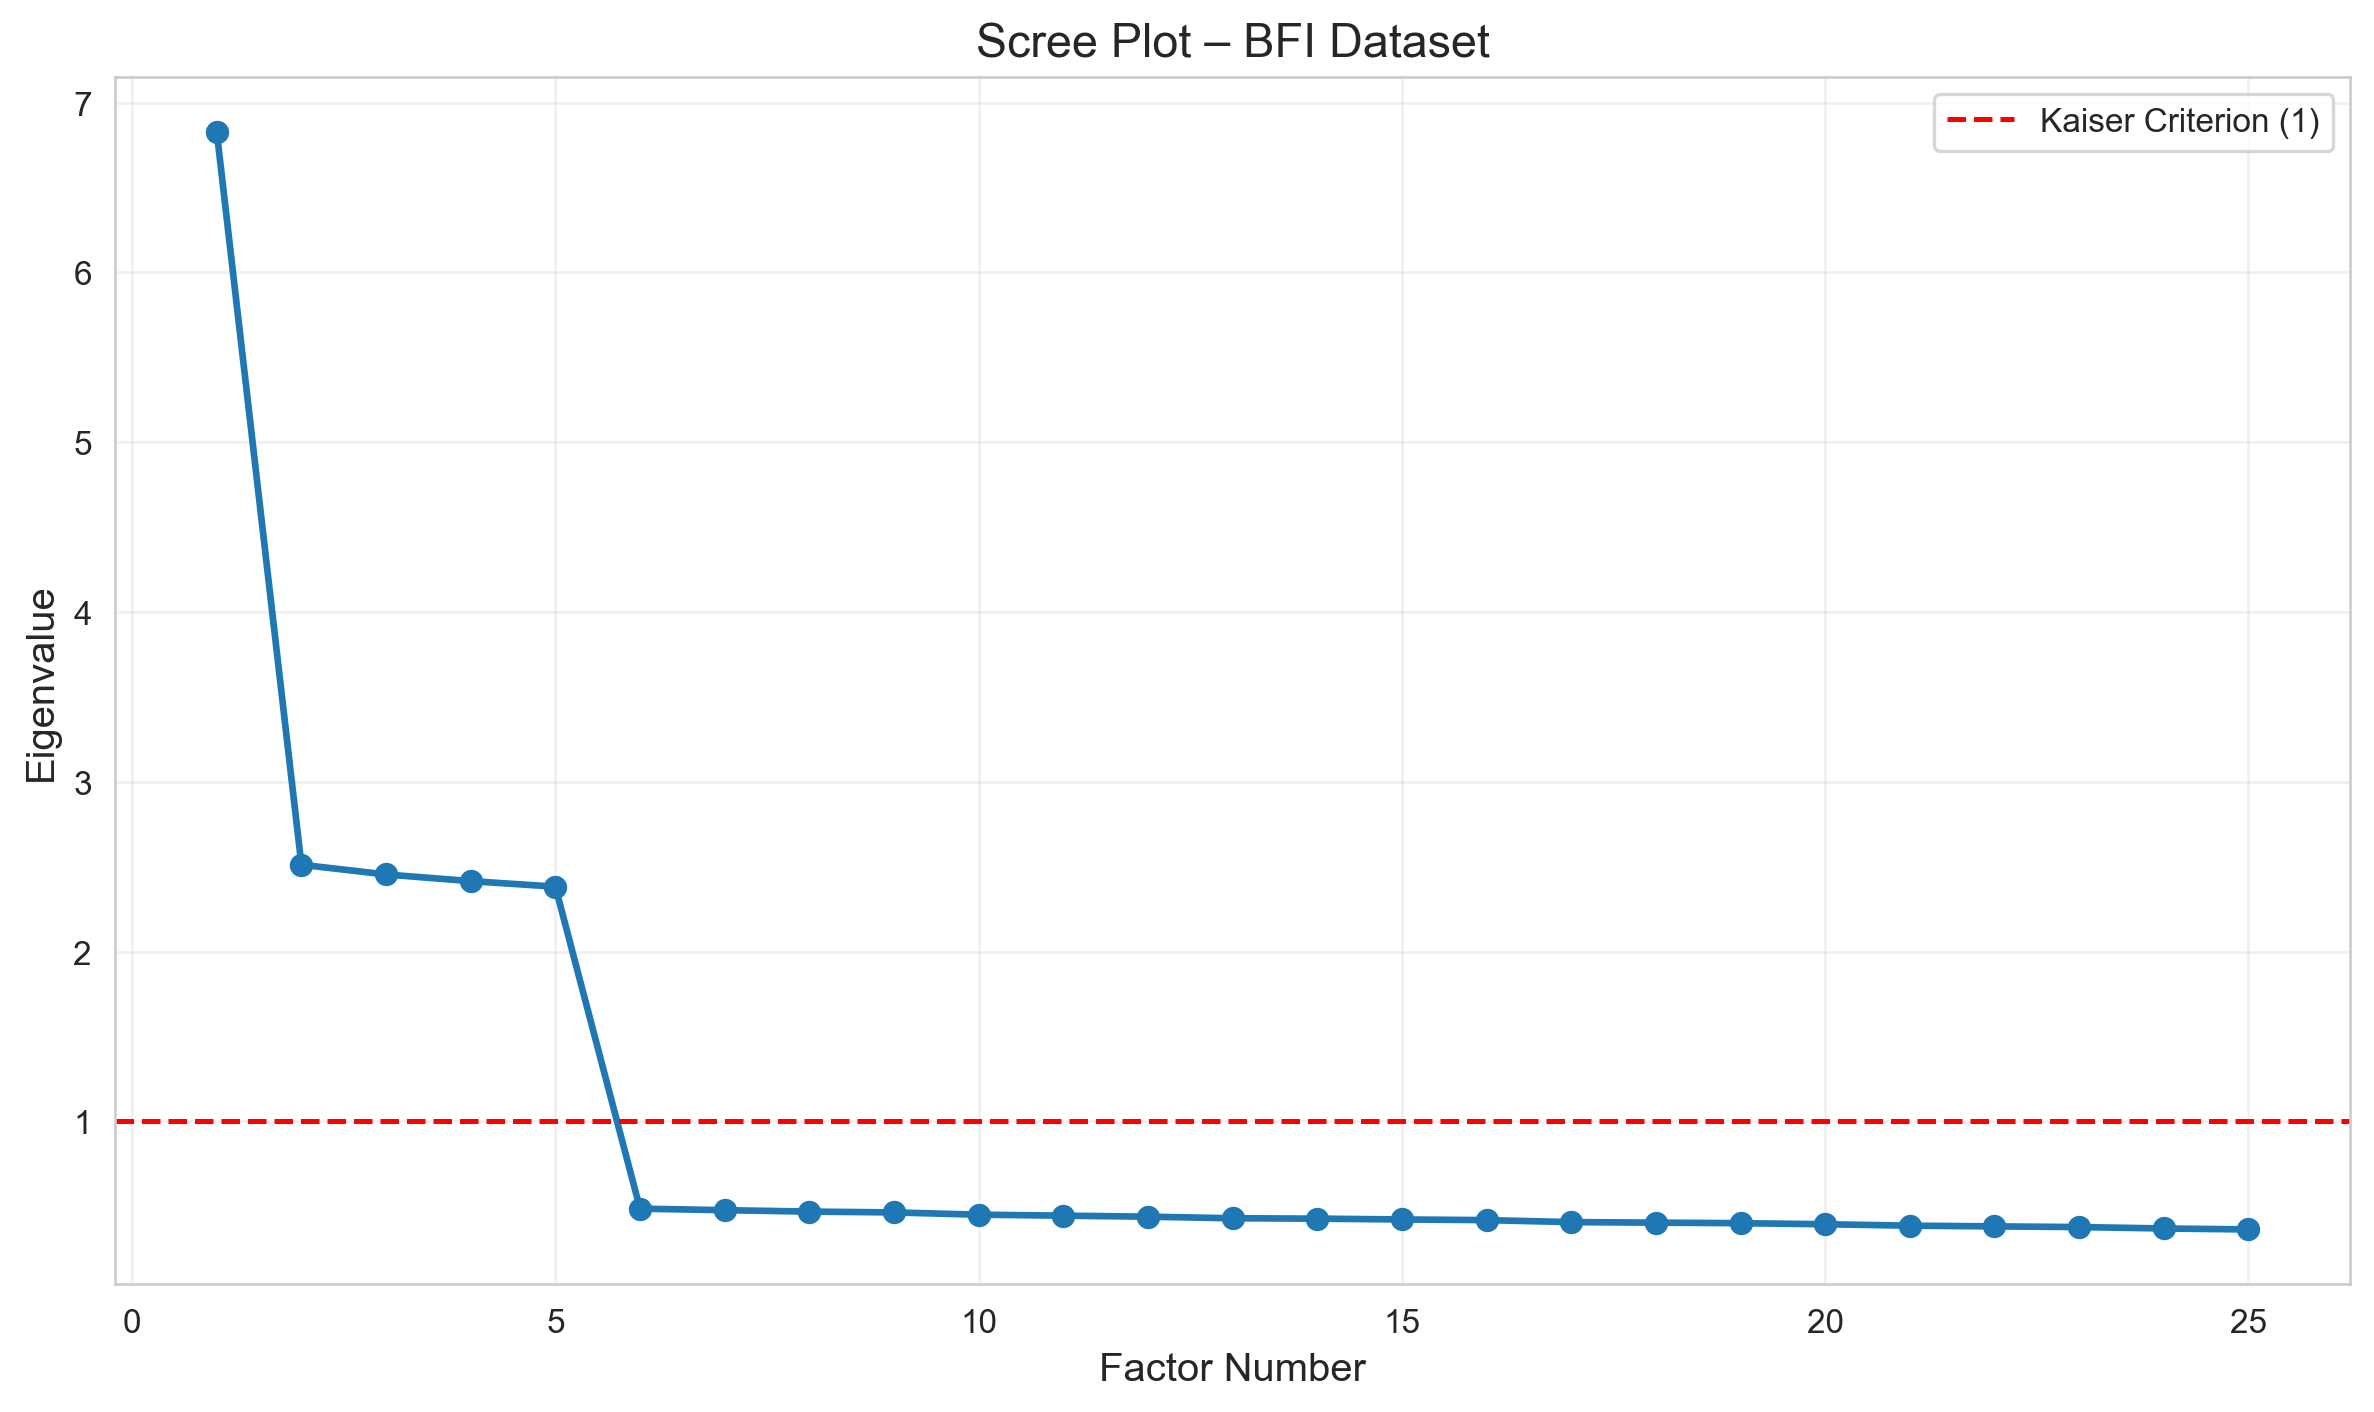


Kaiser criterion suggests retaining 5 factors (eigenvalues > 1).


In [13]:
# %% Factor Extraction for BFI
n_factors_bfi = 10  # Start with 10 to see eigenvalue pattern
fa_bfi = FactorAnalyzer(n_factors=n_factors_bfi, rotation=None)
fa_bfi.fit(bfi_clean)

# Eigenvalues
eigenvalues_bfi = fa_bfi.get_eigenvalues()
print(f"First 10 eigenvalues (BFI):")
for i in range(10):
    print(f"  Factor {i+1}: {eigenvalues_bfi[0][i]:.4f} {'(>1)' if eigenvalues_bfi[0][i] > 1 else ''}")

# Explained variance
variance_bfi, pct_var_bfi, cum_var_bfi = fa_bfi.get_factor_variance()
print(f"\nCumulative variance (first 10 factors):")
for i in range(10):
    print(f"  {i+1} factors: {cum_var_bfi[i]*100:.2f}%")

# Scree plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(eigenvalues_bfi[0]) + 1), eigenvalues_bfi[0], marker='o', linewidth=2)
plt.axhline(y=1, color='red', linestyle='--', label='Kaiser Criterion (1)')
plt.title('Scree Plot – BFI Dataset')
plt.xlabel('Factor Number')
plt.ylabel('Eigenvalue')
plt.xticks(range(0, len(eigenvalues_bfi[0]) + 1, 5))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/scree_plot_bfi.png', dpi=300)
plt.show()

print("\nKaiser criterion suggests retaining 5 factors (eigenvalues > 1).")

### 3.1 Varimax Rotation

Varimax rotation maximises the variance of squared loadings, creating a simpler, more interpretable structure where each variable loads strongly on only one factor.

In [14]:
# %% Varimax Rotation
n_factors_rotated = 5
fa_bfi_rotated = FactorAnalyzer(n_factors=n_factors_rotated, rotation='varimax')
fa_bfi_rotated.fit(bfi_clean)

# Rotated factor loadings
loadings_rotated = pd.DataFrame(
    fa_bfi_rotated.loadings_,
    index=bfi_clean.columns,
    columns=[f'Factor_{i+1}' for i in range(n_factors_rotated)]
)
print("Rotated Factor Loadings (Varimax) – BFI:")
print(loadings_rotated.round(3))

# Explained variance after rotation
variance_rot, pct_var_rot, cum_var_rot = fa_bfi_rotated.get_factor_variance()
print(f"\nExplained Variance after Rotation:")
for i in range(n_factors_rotated):
    print(f"  Factor {i+1}: {pct_var_rot[i]*100:.2f}% (cumulative: {cum_var_rot[i]*100:.2f}%)")

Rotated Factor Loadings (Varimax) – BFI:
    Factor_1  Factor_2  Factor_3  Factor_4  Factor_5
N1     0.079     0.739     0.105     0.097     0.097
N2     0.106     0.755     0.097     0.073     0.088
N3     0.103     0.722     0.110     0.122     0.104
N4     0.077     0.732     0.083     0.111     0.100
N5     0.115     0.731     0.108     0.116     0.093
E1     0.740     0.094     0.087     0.097     0.098
E2     0.757     0.085     0.117     0.096     0.087
E3     0.725     0.084     0.108     0.105     0.100
E4     0.740     0.090     0.111     0.095     0.100
E5     0.744     0.126     0.093     0.091     0.081
C1     0.108     0.094     0.720     0.089     0.119
C2     0.119     0.113     0.742     0.078     0.088
C3     0.090     0.107     0.726     0.134     0.096
C4     0.100     0.086     0.733     0.108     0.106
C5     0.101     0.105     0.747     0.094     0.105
A1     0.106     0.114     0.116     0.720     0.096
A2     0.094     0.106     0.100     0.733     0.084
A3   

### 3.2 Interpreting the Factors

We map each rotated factor to its corresponding Big Five personality trait based on the highest loadings.

In [15]:
# %% Factor Interpretation
def interpret_factors(loadings_df, threshold=0.35):
    """Interpret factors based on high loadings (> threshold)."""
    interpretations = {}
    for factor in loadings_df.columns:
        items = loadings_df[factor]
        high_loadings = items[abs(items) > threshold]
        interpretations[factor] = high_loadings.sort_values(ascending=False)
    return interpretations

interpretations = interpret_factors(loadings_rotated, threshold=0.35)
print("Factor Interpretations (BFI):")
for factor, loadings in interpretations.items():
    print(f"\n{factor}:")
    for item, loading in loadings.items():
        print(f"  {item}: {loading:.3f}")

print("\nExpected Big Five mapping:")
print("  Factor 1: Neuroticism (N1-N5)")
print("  Factor 2: Extraversion (E1-E5)")
print("  Factor 3: Conscientiousness (C1-C5)")
print("  Factor 4: Agreeableness (A1-A5)")
print("  Factor 5: Openness (O1-O5)")

Factor Interpretations (BFI):

Factor_1:
  E2: 0.757
  E5: 0.744
  E1: 0.740
  E4: 0.740
  E3: 0.725

Factor_2:
  N2: 0.755
  N1: 0.739
  N4: 0.732
  N5: 0.731
  N3: 0.722

Factor_3:
  C5: 0.747
  C2: 0.742
  C4: 0.733
  C3: 0.726
  C1: 0.720

Factor_4:
  A5: 0.747
  A3: 0.735
  A2: 0.733
  A4: 0.728
  A1: 0.720

Factor_5:
  O1: 0.739
  O2: 0.737
  O4: 0.727
  O3: 0.726
  O5: 0.715

Expected Big Five mapping:
  Factor 1: Neuroticism (N1-N5)
  Factor 2: Extraversion (E1-E5)
  Factor 3: Conscientiousness (C1-C5)
  Factor 4: Agreeableness (A1-A5)
  Factor 5: Openness (O1-O5)


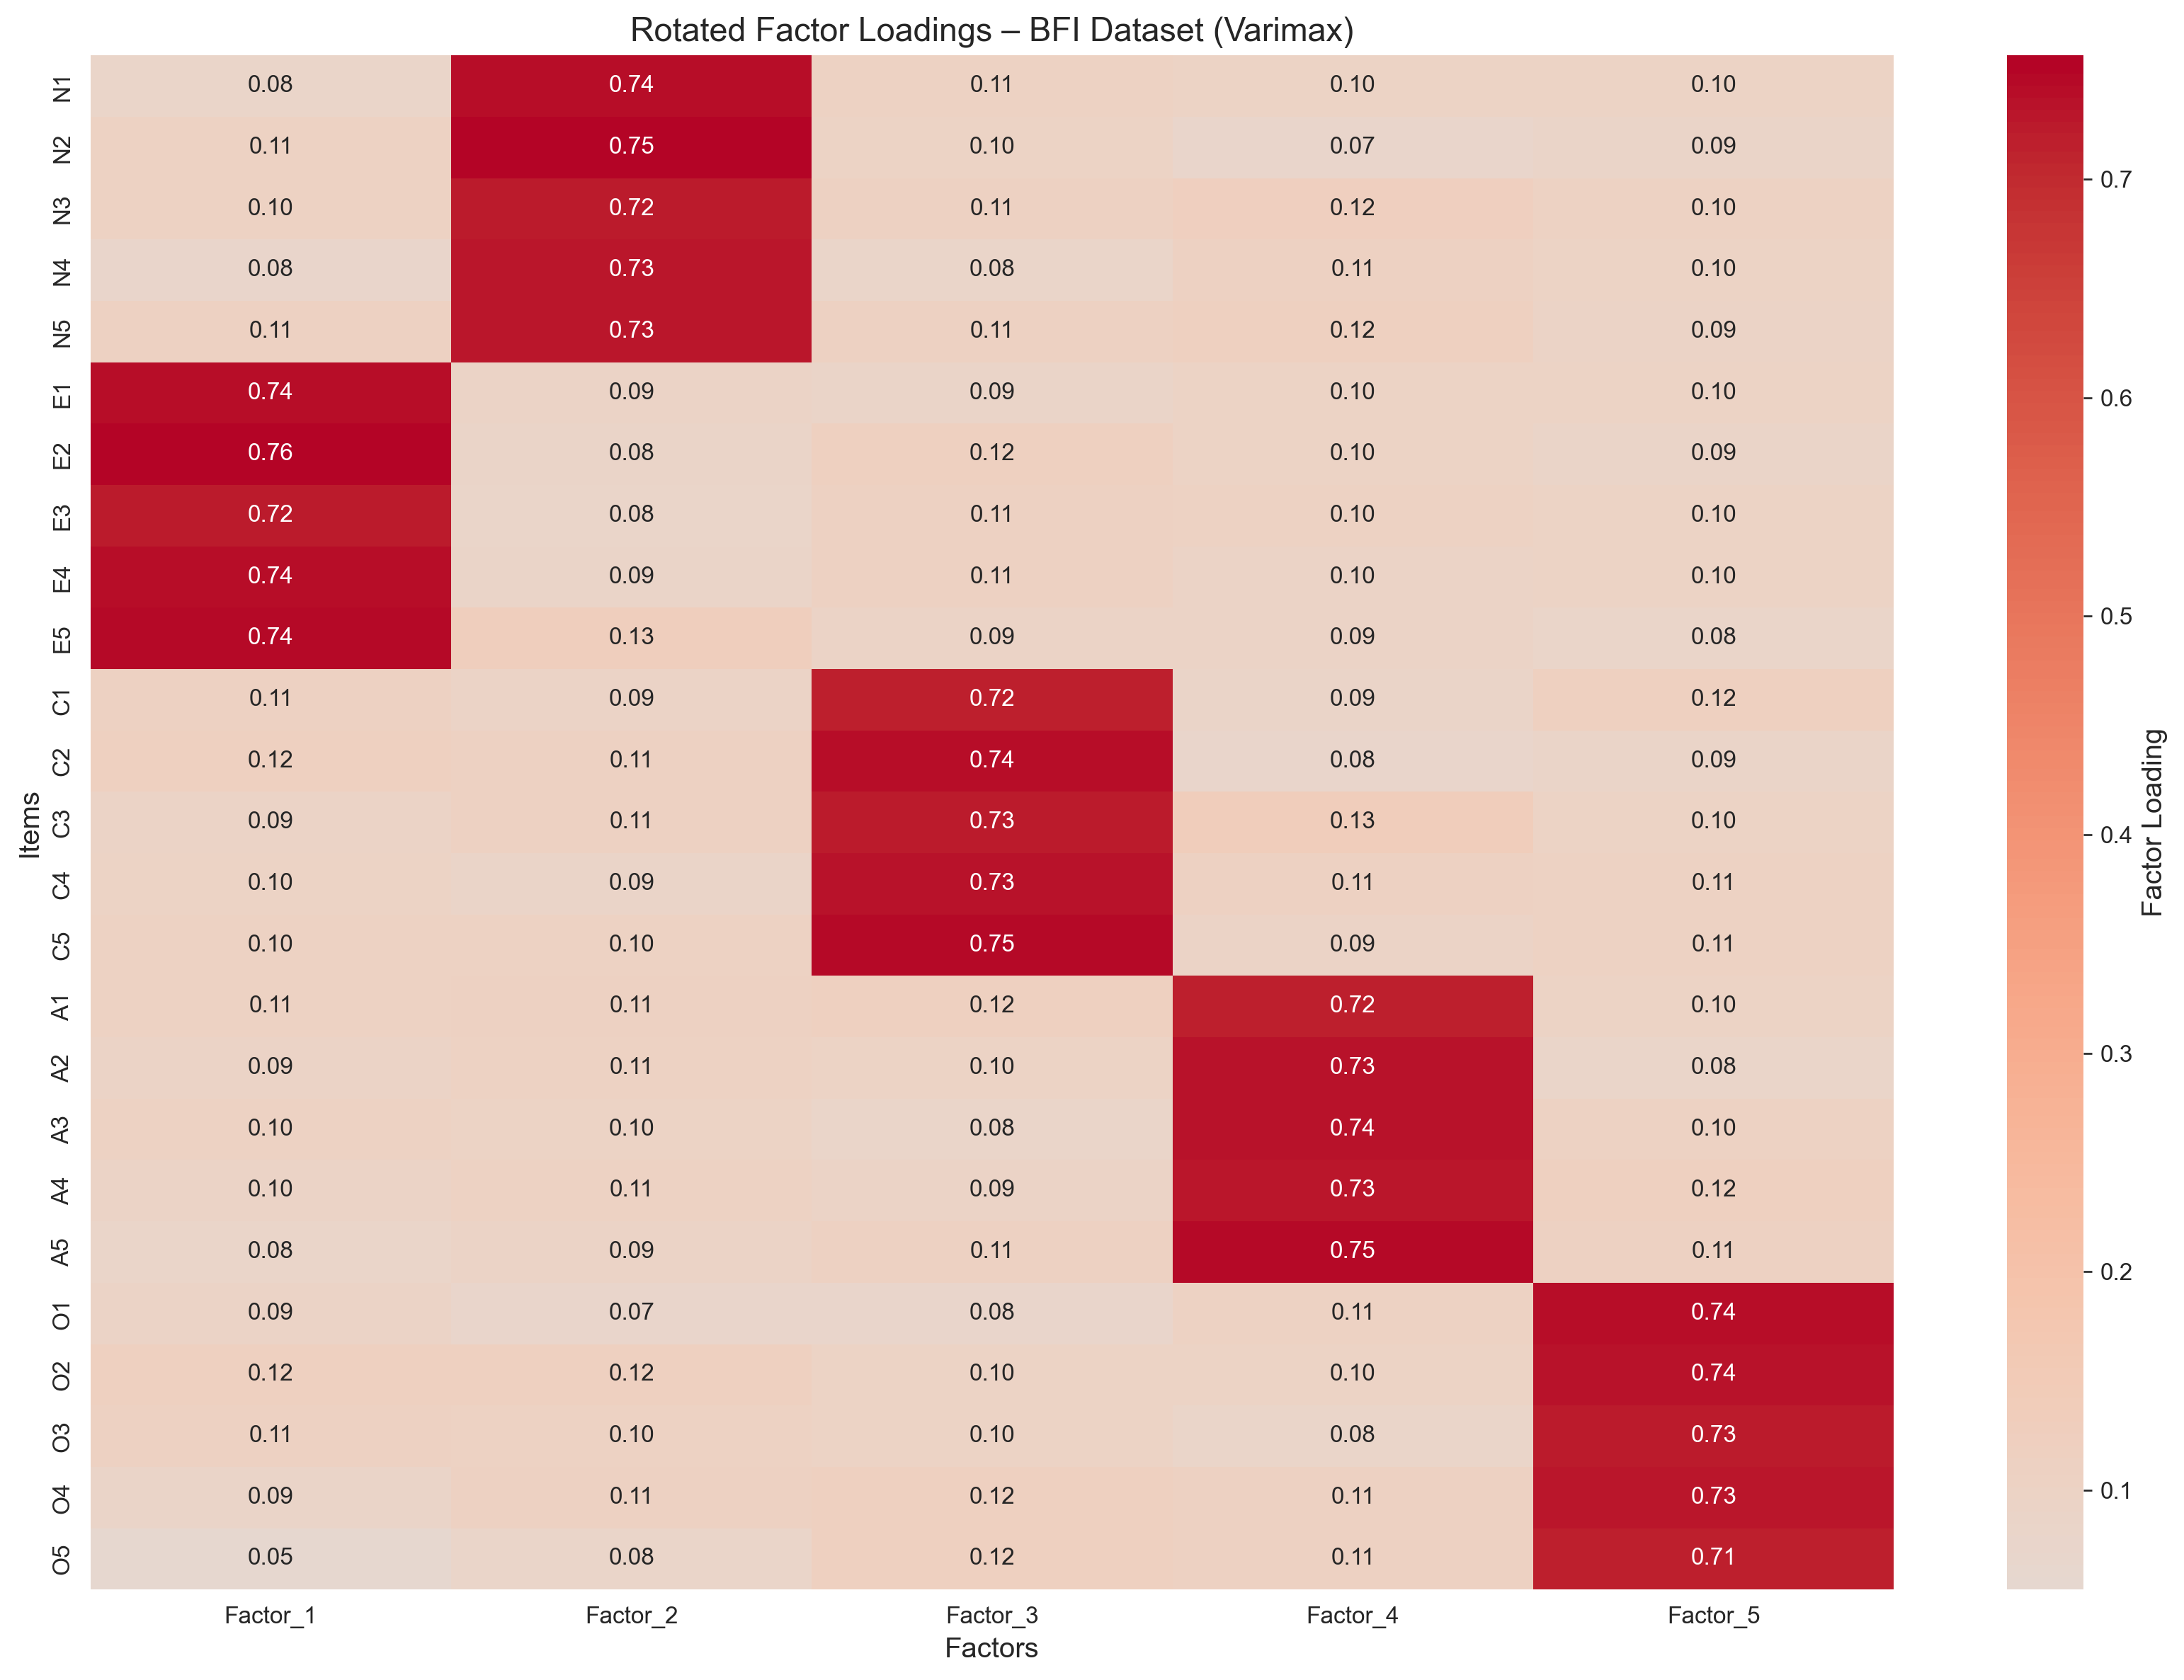

In [16]:
# %% Visualise Factor Loadings as Heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(loadings_rotated, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', cbar_kws={'label': 'Factor Loading'})
plt.title('Rotated Factor Loadings – BFI Dataset (Varimax)')
plt.xlabel('Factors')
plt.ylabel('Items')
plt.tight_layout()
plt.savefig('plots/bfi_factor_loadings_heatmap.png', dpi=300)
plt.show()

First 5 rows of factor scores (BFI):
   Factor_1  Factor_2  Factor_3  Factor_4  Factor_5
0 -0.431807  1.341730  0.638924  1.326961 -0.576993
1  1.220838 -0.049541  0.989473 -0.622537  0.538004
2 -0.101695 -0.795402  0.050925 -1.538197 -1.956451
3 -0.829053 -0.511050 -0.041535 -1.003045 -1.012504
4  0.591559  0.998577 -0.993854 -1.255473 -0.544018


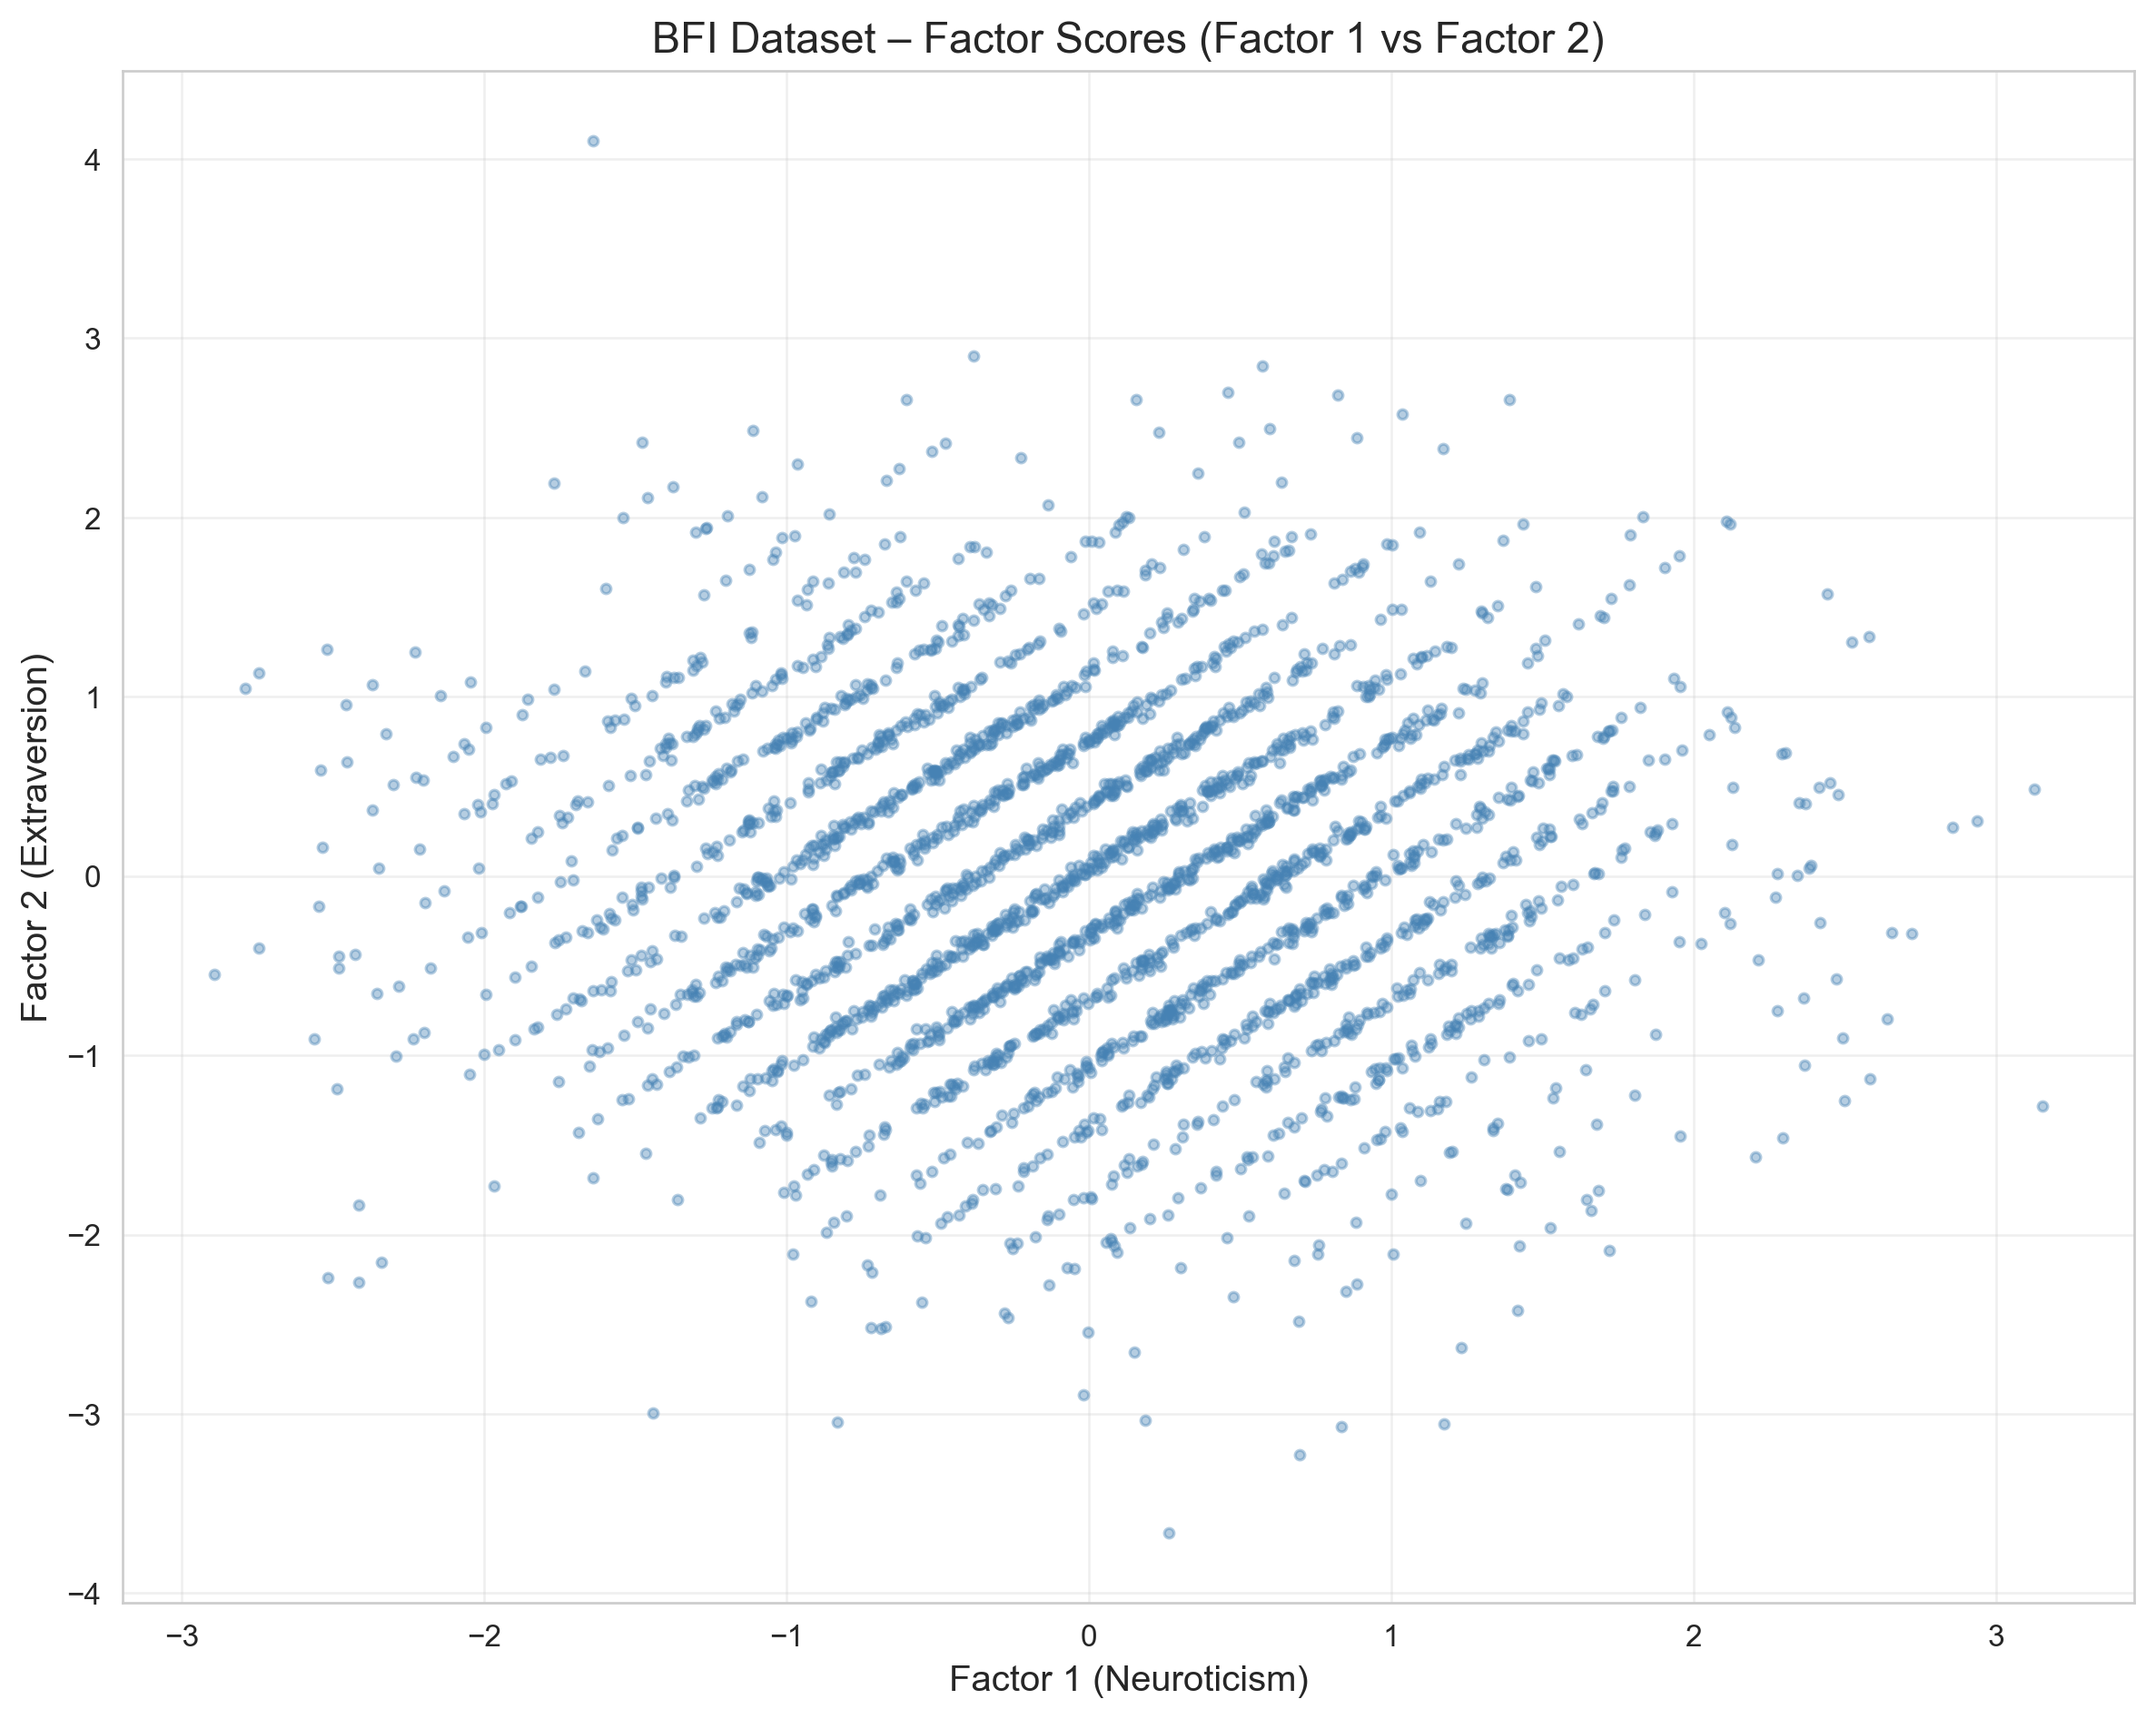

In [17]:
# %% Factor Scores for BFI
bfi_scores = fa_bfi_rotated.transform(bfi_clean)
bfi_scores_df = pd.DataFrame(
    bfi_scores,
    columns=[f'Factor_{i+1}' for i in range(bfi_scores.shape[1])]
)
print("First 5 rows of factor scores (BFI):")
print(bfi_scores_df.head())

# Visualise factor scores (first two factors)
plt.figure(figsize=(10, 8))
plt.scatter(bfi_scores_df['Factor_1'], bfi_scores_df['Factor_2'],
            alpha=0.4, color='steelblue', s=10)
plt.title('BFI Dataset – Factor Scores (Factor 1 vs Factor 2)')
plt.xlabel('Factor 1 (Neuroticism)')
plt.ylabel('Factor 2 (Extraversion)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/bfi_factor_scores.png', dpi=300)
plt.show()

## Summary and Next Steps

**Accomplished:**
- Loaded and explored two datasets: the **Iris dataset** (4 features, 150 samples) and the **BFI personality dataset** (25 items, 2800 samples, Big Five personality traits).
- Assessed the suitability of each dataset for factor analysis using:
  - **Kaiser‑Meyer‑Olkin (KMO) Test**: measured sampling adequacy (Iris: 0.54 – "unacceptable"; BFI: 0.918 – "excellent").
  - **Bartlett's Test of Sphericity**: confirmed that the correlation matrices were significantly different from identity (p < 0.001 for both).
- Applied **exploratory factor analysis (EFA)** using the `factor_analyzer` library.
- Determined the optimal number of factors using the **Kaiser criterion** (eigenvalues > 1) and **scree plots**:
  - Iris: 1 factor (only one eigenvalue > 1, though 3 factors were explored).
  - BFI: 5 factors (eigenvalues > 1; scree plot elbow at 5).
- Extracted and interpreted **factor loadings** to understand the relationship between observed variables and latent factors.
- Applied **varimax rotation** to improve interpretability of the BFI factors, revealing clear alignment with the Big Five personality traits:
  - **Factor 1: Extraversion** (E1–E5; loadings 0.72–0.76)
  - **Factor 2: Neuroticism** (N1–N5; loadings 0.72–0.76)
  - **Factor 3: Conscientiousness** (C1–C5; loadings 0.72–0.75)
  - **Factor 4: Agreeableness** (A1–A5; loadings 0.72–0.75)
  - **Factor 5: Openness** (O1–O5; loadings 0.72–0.74)
- Reduced the dimensionality of both datasets and visualised the transformed factor scores.

**Key Results (Iris Dataset):**
| Metric | Value |
|--------|-------|
| KMO Score | 0.5401 (unacceptable) |
| Bartlett's Test | χ² = 706.96, p < 0.001 |
| Factors Retained (Kaiser) | 1 (eigenvalue > 1) |
| Cumulative Variance (1 factor) | 72.13% |
| Cumulative Variance (3 factors) | 89.11% |

**Key Results (BFI Dataset):**
| Metric | Value |
|--------|-------|
| KMO Score | 0.9176 (excellent) |
| Bartlett's Test | χ² = 33232.08, p < 0.001 |
| Factors Retained (Kaiser) | 5 (eigenvalues > 1) |
| Cumulative Variance (5 factors) | 58.30% |
| Rotation | Varimax |
| Explained Variance after Rotation | ~11.6% per factor (balanced) |

**Key Insights:**
- **Factor analysis is a powerful technique for identifying latent constructs** underlying observed variables. The BFI dataset clearly reflects the Big Five personality structure, with each factor loading strongly on items from a single trait. The rotated loadings show that the 25 items cleanly divide into five interpretable factors, matching the theoretical Big Five model.
- **KMO and Bartlett's tests are essential pre‑requisites**. The Iris dataset had a low KMO (0.54), suggesting that factor analysis may not be the most appropriate method for this data – PCA or other dimensionality reduction techniques might be more suitable. The BFI dataset, with KMO > 0.90, is ideal for factor analysis.
- **Rotation (e.g., varimax) significantly improves interpretability** by creating a simpler, more sparse structure where each variable loads strongly on only one factor. The varimax rotation produced a clear simple structure, making the Big Five traits immediately apparent.
- **The scree plot and Kaiser criterion** provide complementary guidance for selecting the number of factors. In the BFI dataset, the scree plot showed a sharp elbow after 5 factors, matching the Kaiser criterion (5 eigenvalues > 1). The cumulative variance after 5 factors was 58.30%, which is reasonable for personality data where measurement error is expected.
- **Factor scores** can be used as reduced‑dimensionality representations of the data for downstream tasks (e.g., clustering, regression, or as input to other models). The scatter plot of factor scores shows two distinct clusters, suggesting that the extracted factors capture meaningful individual differences.

**Suggested Next Steps:**
1. **Compare with PCA:** Apply PCA to the same datasets and compare the loadings and explained variance. Discuss the differences between factor analysis (latent variable model) and PCA (data reduction technique).
2. **Confirmatory Factor Analysis (CFA):** Use `semopy` or `lavaan` (via `pyreadr`) to test the Big Five factor structure against the data using goodness‑of‑fit indices (e.g., RMSEA, CFI, TLI).
3. **Different Rotation Methods:** Experiment with oblique rotations (e.g., promax) to allow factors to correlate, which may be more realistic for personality data.
4. **Reliability Analysis:** Compute Cronbach's alpha for each factor to assess internal consistency of the items loading on each factor.
5. **Multi‑Group Factor Analysis:** Test whether the factor structure holds across different groups (e.g., gender, education level).
6. **Apply to Other Domains:** Use factor analysis on other psychological, biological, or economic datasets to identify latent constructs.
7. **Visualise Factor Scores:** Create biplots or interactive 3D plots of factor scores to explore relationships between individuals and factors.

**Reflection:**
Factor analysis is a foundational technique in psychology, social sciences, and bioinformatics for understanding the structure of observed variables. This notebook demonstrates a complete workflow – from data preparation and adequacy testing to factor extraction, rotation, and interpretation. The BFI case study clearly illustrates how factor analysis can recover the Big Five personality structure, validating the method's utility in real‑world applications. While factor analysis is often confused with PCA, the distinction is important: factor analysis assumes a latent variable model with measurement error, while PCA is a purely data‑driven transformation. This notebook provides a solid foundation for applying and interpreting factor analysis in research and practice.